# ClickHouse API Tutorial — Session Purchase Forecasting (Oct 2019)

## Objective (Learn ClickHouse in ~60 minutes)
We build a small analytics platform using **ClickHouse** as the core OLAP engine.

- **Dataset**: `data/2019-Oct.csv` (event log)
- **Hypothesis**: Using the **first N events** in a `user_session` (start with **N=5**), we can predict whether the session will have a **purchase later**.
- **Label**: `has_purchase_in_session` ∈ {0,1}

## What this notebook does
- Creates a robust raw→typed ingestion pipeline in ClickHouse (handles `event_time` strings like `... UTC`)
- Runs OLAP/funnel analytics queries
- Builds a physical ML training table in ClickHouse: `training_sessions_n5`
- Creates summary tables for Grafana

Next notebook: `clickhouse.example.ipynb` trains Logistic Regression + XGBoost and writes predictions back into ClickHouse.


## Step 1/9 — Setup + connect

**What this does**: Imports libraries, points Python at `/app` (so we can import helper code), and opens a ClickHouse connection.

**Why we do it**: Every step below is driven by SQL. If we can connect and run a trivial query, we know the environment is healthy.

**What to look for in the output (and how to interpret it)**:
- **ClickHouse version**: confirms you’re connected to the server you think you are.
- **Database**: should be `ecomm` (unless you changed `CLICKHOUSE_DB`). If it’s different, later tables may appear “missing”.

**Common issues + fixes**:
- **Connection refused / timeout**: start the container: `docker compose up -d clickhouse`.
- **Wrong database**: check `CLICKHOUSE_DB` env var and defaults in `clickhouse_utils.py`.


In [ ]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path("/app")))


import pandas as pd
import plotly.express as px

from clickhouse_utils import get_client, print_kv, ch_df

print("Step 1/9: Setup + connect")

DATA_PATH = Path("/app/data/2019-Oct.csv")
print_kv("Dataset path", DATA_PATH)

client = get_client()
print_kv("ClickHouse version", client.execute("SELECT version()"))
print_kv("Database", client.execute("SELECT currentDatabase()"))

Step 1/9: Setup + connect
Dataset path: /app/data/2019-Oct.csv
ClickHouse version: [('26.3.9.8',)]
Database: [('ecomm',)]


## Step 3/9 — Confirm ingestion happened (fast check)

**What this does**: Verifies that the dataset was ingested into ClickHouse by checking row counts in `events_raw` and `events_typed`.

**Why we do it**: The CSV is large; ingestion is intentionally done by `./docker_ingest.sh` (fast, reproducible) instead of loading gigabytes into pandas. This check prevents “mystery failures” later.

**What to look for in the output (and how to interpret it)**:
- **Both counts > 0**: ingestion actually happened.
- **Counts match**: the raw→typed materialized view is working and successfully parsed timestamps.

**Common issues + fixes**:
- **Table not found / zero rows**: run `./docker_ingest.sh` from project root, then rerun from Step 1.
- **Raw > typed**: some timestamps failed parsing. Re-check the MV logic (timestamp parsing + `UTC` string cleanup) in `docker_ingest.sh`.


In [ ]:
print("Step 3/9: Verify data is already ingested (fast)")

# Step 2/9 is performed in the script file.

# For a linear, reproducible run we ingest with ClickHouse directly:
#   ./docker_ingest.sh
# This keeps the notebook fast and avoids loading a multi-GB CSV in Python.

raw_rows = client.execute("SELECT count() FROM events_raw")[0][0]
typed_rows = client.execute("SELECT count() FROM events_typed")[0][0]
print_kv("events_raw rows", raw_rows)
print_kv("events_typed rows", typed_rows)

if raw_rows == 0 or typed_rows == 0:
    raise RuntimeError(
        "Data not ingested yet. Run: ./docker_ingest.sh (from project root), then rerun this notebook."
    )

print("Data is ready. Continuing with analytics + feature engineering...")


Step 3/9: Verify data is already ingested (fast)
events_raw rows: 42448764
events_typed rows: 42448764
Data is ready. Continuing with analytics + feature engineering...


## Step 4/9 — Sanity check the typed table

**What this does**: Runs two quick queries against `events_typed` to validate the dataset (timestamp range, row counts, and which `event_type`s exist).

**Why we do it**: If `events_typed` is wrong, every downstream table (labels, features, training data) will be wrong too. This is the cheapest place to catch ingestion/typing mistakes.

**What to look for in the output (and how to interpret it)**:
- **`min_time` / `max_time`**: should span the expected month (Oct 2019).
- **`rows`**: should be large (tens of millions) but finite.
- **`users` / `sessions`**: should be large; if `sessions` is tiny or 0, ingestion failed.
- **Event types**: you should see the expected set (e.g., `view`, `cart`, `purchase`). If an event type is missing, any feature depending on it will become constant (often all zeros).

**ClickHouse notes**:
- `uniqExact(x)` is an **exact** distinct count (accurate, sometimes slower than approximate `uniq*`).

**Common issues + fixes**:
- **Missing/empty tables**: rerun `./docker_ingest.sh`.
- **Raw rows ≠ typed rows**: timestamp parsing failed for some rows; check the raw→typed materialized view logic in `docker_ingest.sh`.


In [ ]:
print("Step 4/9: Minimal sanity checks on typed data")

# Query 1 (`q_basic`): Returns the earliest/latest event timestamp, total event rows, distinct users, and distinct sessions from `events_typed`.

q_basic = """
SELECT
  min(event_time_dt) AS min_time,
  max(event_time_dt) AS max_time,
  count() AS rows,
  uniqExact(user_id) AS users,
  uniqExact(user_session) AS sessions
FROM events_typed
"""
print(ch_df(client, q_basic, ["min_time","max_time","rows","users","sessions"]))

# Query 2 (`q_event_types`): Counts how many rows exist per `event_type` and sorts them descending so the most common event types appear first.

q_event_types = """
SELECT event_type, count() AS n
FROM events_typed
GROUP BY event_type
ORDER BY n DESC
"""
print(ch_df(client, q_event_types, ["event_type","n"]).head(10))

Step 4/9: Minimal sanity checks on typed data
                   min_time                  max_time      rows    users  \
0 2019-10-01 00:00:00+00:00 2019-10-31 23:59:59+00:00  42448764  3022290   

   sessions  
0   9244422  
  event_type         n
0       view  40779399
1       cart    926516
2   purchase    742849


## Step 5/9 — Analytics: `hourly_funnel` + funnel charts + top categories

**What this does**:
1. Creates **`hourly_funnel`** (`SummingMergeTree`) and **`mv_hourly_funnel`**, then **backfills** from `events_typed` (MVs only see *new* inserts; backfill loads history).
2. Builds the **daily funnel line chart** by reading **`hourly_funnel`** and rolling up with `toDate(event_hour)` + `sum(...)` (same metrics as before, but **one stored source** Grafana can query too).
3. Runs **top categories by revenue** directly on **`events_typed`** (needs `category_code` / `price` — not in the hourly rollup).

**Why we do it**: Avoid maintaining the same funnel counts in two places. The notebook and Grafana share **`hourly_funnel`**.

**What to look for**:
- **`hourly_funnel` row count** roughly matches distinct hours in the month.
- **Daily views > carts > purchases**; **`purchase_per_view`** is a small fraction.
- **Top categories** look plausible.

**ClickHouse notes**:
- `countIf` / `sumIf` in the MV definition; `SummingMergeTree` stores **additive** counters. When aggregating further (daily rollup), use **`sum(views)`**, **`sum(carts)`**, **`sum(purchases)`** over hours.

**Common issues + fixes**:
- **Empty `hourly_funnel`**: confirm `events_typed` has rows (Steps 3–4), then rerun this cell.
- **All zeros in charts**: ingestion or MV wiring issue.


Step 5/9: hourly_funnel (MV + backfill) + daily funnel from rollup + top categories
hourly_funnel rows: [(744,)]
Preview hourly_funnel:
           event_hour  views  carts  purchases
0 2019-10-01 00:00:00   1070      3         10
1 2019-10-01 01:00:00    121      0          0
2 2019-10-01 02:00:00  22326    244        316
3 2019-10-01 03:00:00  47951    613        845
4 2019-10-01 04:00:00  53390    879       1021
   event_date    views  carts  purchases  purchase_per_view
0  2019-10-01  1208280  16658      19307           0.015979
1  2019-10-02  1154591  17268      19469           0.016862
2  2019-10-03  1088725  19323      19255           0.017686
3  2019-10-04  1346320  43829      27041           0.020085
4  2019-10-05  1271348  35497      23494           0.018480


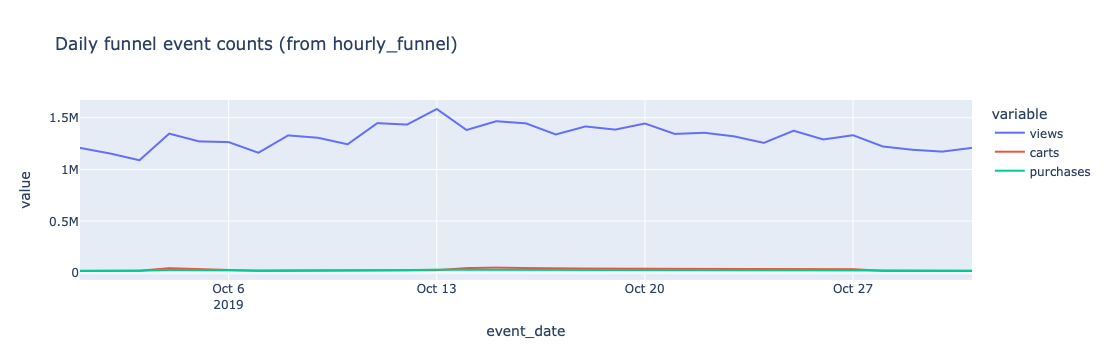

                      category_code  purchases       revenue
0            electronics.smartphone     338018  1.570496e+08
1                              None     173425  2.292494e+07
2                computers.notebook      15590  8.979887e+06
3              electronics.video.tv      21565  8.423408e+06
4                electronics.clocks      17906  4.818305e+06
5         appliances.kitchen.washer      16148  4.658647e+06
6  appliances.kitchen.refrigerators      11218  3.830077e+06
7       electronics.audio.headphone      30503  3.539127e+06
8     appliances.environment.vacuum      12378  1.716425e+06
9                electronics.tablet       5603  1.610974e+06


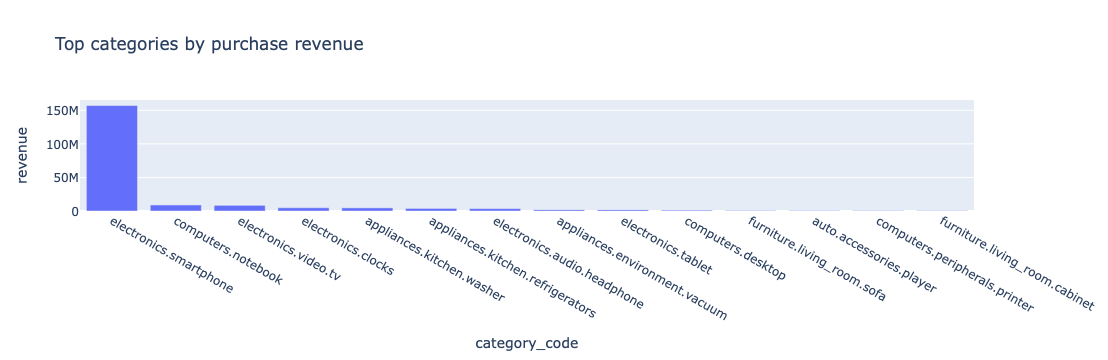

In [ ]:
print("Step 5/9: hourly_funnel (MV + backfill) + daily funnel from rollup + top categories")

# Shared SELECT: one definition for MV and backfill (avoids drift).
HOURLY_FUNNEL_SELECT = """
SELECT
  toStartOfHour(event_time_dt) AS event_hour,
  countIf(event_type = 'view') AS views,
  countIf(event_type = 'cart') AS carts,
  countIf(event_type = 'purchase') AS purchases
FROM events_typed
GROUP BY event_hour
"""

client.execute("DROP TABLE IF EXISTS hourly_funnel")
client.execute(
    """
    CREATE TABLE hourly_funnel
    (
      event_hour DateTime,
      views UInt64,
      carts UInt64,
      purchases UInt64
    )
    ENGINE = SummingMergeTree
    ORDER BY (event_hour)
    """
)

client.execute("DROP VIEW IF EXISTS mv_hourly_funnel")
client.execute(
    f"""
    CREATE MATERIALIZED VIEW mv_hourly_funnel
    TO hourly_funnel
    AS
    {HOURLY_FUNNEL_SELECT}
    """
)

client.execute("TRUNCATE TABLE hourly_funnel")
client.execute(f"INSERT INTO hourly_funnel {HOURLY_FUNNEL_SELECT}")

print_kv("hourly_funnel rows", client.execute("SELECT count() FROM hourly_funnel"))
print("Preview hourly_funnel:")
print(ch_df(client, "SELECT * FROM hourly_funnel ORDER BY event_hour LIMIT 5", ["event_hour", "views", "carts", "purchases"]))

# Daily funnel from rollup (Grafana-friendly source of truth)
q_funnel_daily = """
SELECT
  event_date,
  views,
  carts,
  purchases,
  purchases / nullIf(views, 0) AS purchase_per_view
FROM (
  SELECT
    toDate(event_hour) AS event_date,
    sum(views) AS views,
    sum(carts) AS carts,
    sum(purchases) AS purchases
  FROM hourly_funnel
  GROUP BY event_date
)
ORDER BY event_date
LIMIT 31
"""

df_funnel = ch_df(
    client,
    q_funnel_daily,
    ["event_date", "views", "carts", "purchases", "purchase_per_view"],
)
print(df_funnel.head(5))

fig = px.line(df_funnel, x="event_date", y=["views", "carts", "purchases"], title="Daily funnel event counts (from hourly_funnel)")
fig.show()

# Top categories still need event-level columns
q_top_cat = """
SELECT
  category_code,
  countIf(event_type = 'purchase') AS purchases,
  sumIf(price, event_type = 'purchase') AS revenue
FROM events_typed
GROUP BY category_code
ORDER BY revenue DESC
LIMIT 15
"""

df_top_cat = ch_df(client, q_top_cat, ["category_code", "purchases", "revenue"])
print(df_top_cat.head(10))

fig2 = px.bar(df_top_cat, x="category_code", y="revenue", title="Top categories by purchase revenue")
fig2.show()



## Step 6/9 — Build the label: session outcomes

**What this does**: Aggregates the event log into **one row per `user_session`** and defines the supervised-learning label `has_purchase_in_session` (1 if the session contains any purchase).

**Why we do it**: Our prediction task is session-level (“will this session purchase?”). Creating a clean label table makes feature engineering and model training straightforward.

**What to look for in the output (and how to interpret it)**:
- You should see **two rows** (0/1) with counts of sessions.
- The **positive class (1)** will usually be a minority. That’s normal and affects metric choice.

**ClickHouse notes**:
- `anyHeavy(user_id)` picks a representative `user_id` per session. It’s a pragmatic way to carry user identity through a session-level aggregate.
- `countIf(...)` is used to count each event type per session.

**Common issues + fixes**:
- **All sessions are 0**: check that `purchase` events exist (Step 4).
- **Huge positive rate**: double-check event typing and the `event_type` values in `events_typed`.


In [ ]:
print("Step 6/9: Create session outcomes (label table)")

# Query 1: Build a session-level table with counts and the purchase label.
client.execute("DROP TABLE IF EXISTS session_outcomes")
client.execute(
    """
    CREATE TABLE session_outcomes
    ENGINE = MergeTree
    ORDER BY (user_session)
    AS
    SELECT
      user_session,
      anyHeavy(user_id) AS user_id,
      min(event_time_dt) AS session_start,
      max(event_time_dt) AS session_end,
      dateDiff('second', session_start, session_end) AS session_duration_sec,
      count() AS session_events,
      countIf(event_type='view') AS n_view,
      countIf(event_type='cart') AS n_cart,
      countIf(event_type='purchase') AS n_purchase,
      (n_purchase > 0) AS has_purchase_in_session
    FROM events_typed
    WHERE user_session != ''
    GROUP BY user_session
    """
)

q_sample = """
select * from session_outcomes limit 5
"""

print(ch_df(client,  q_sample, None))

# Query 2 (q_label): Label distribution (how imbalanced is the target?).
q_label = """
SELECT
  has_purchase_in_session,
  count() AS sessions
FROM session_outcomes
GROUP BY has_purchase_in_session
ORDER BY has_purchase_in_session
"""
print(ch_df(client, q_label, ["has_purchase_in_session","sessions"]))

Step 6/9: Create session outcomes (label table)
                           user_session    user_id             session_start  \
0  000003eb-b63e-45d9-9f26-f229057c654a  512483064 2019-10-03 11:28:52+00:00   
1  00000e7e-fd0d-4f9e-b13b-bec0cfd54a2e  544174599 2019-10-28 04:43:35+00:00   
2  0000187f-5276-441c-a945-b8ffc2edcd28  518723895 2019-10-16 07:33:09+00:00   
3  0000434b-083d-4a38-aa94-583ee4b1e378  547153464 2019-10-23 17:46:46+00:00   
4  00005026-a9d1-4e2b-8290-3cc14e4bad89  520649833 2019-10-15 08:02:19+00:00   

                session_end  session_duration_sec  session_events  n_view  \
0 2019-10-03 11:28:52+00:00                     0               1       1   
1 2019-10-28 04:44:53+00:00                    78               4       4   
2 2019-10-16 07:33:09+00:00                     0               1       1   
3 2019-10-23 17:46:46+00:00                     0               1       1   
4 2019-10-15 08:09:02+00:00                   403              11       7   

   n_car

In [ ]:
print(client.execute("EXISTS TABLE session_outcomes"))

[(1,)]


## Step 7/9 — Feature engineering: first-N events (“prefix”) + user history → training table

**What this does**:
- Builds **prefix features** using only the **first N events** in each `user_session` (N=5 here).
- Builds **user-history features** per session (prior sessions, prior purchases, time since last session, historical conversion rate).
- Joins them into a single ML-ready table: `training_sessions_n5`.

**Why we do it**: This matches the real prediction setting: at the beginning of a session, you only know early behavior + the user’s historical behavior, and you want to predict whether a purchase will occur later.

**What to look for in the output (and how to interpret it)**:
- `training_sessions_n5` row count should be large (but smaller than total sessions because we require at least N events).
- The label distribution (0/1) should look similar to `session_outcomes` (but not identical due to the “must have N events” filter).
- History features should behave sensibly:
  - many sessions have `prior_sessions = 0` (first observed session)
  - `hist_conversion_rate` is 0 for first sessions and between 0 and 1 otherwise

**ClickHouse notes**:
- `LIMIT N BY user_session` is a ClickHouse idiom to take the first N rows per group without expensive window functions over the full event table.
- User-history is computed with **window functions** over `session_outcomes` (much smaller than `events_typed`).
- The training-table join is written to avoid high memory usage by joining prefix features to a **column-minimized** `session_user_history` (rather than performing multiple large joins).

**Common issues + fixes**:
- **Memory limit exceeded** during table creation: reduce join width (select fewer columns) and avoid multiple joins; the current pattern is designed for that.
- **History features all zero**: confirm `session_outcomes` has multiple sessions per user (and that you re-ran Step 6 before Step 7).


In [ ]:
print("Step 7/9: Build prefix features (N=5) and training table")

# Query 1: Create prefix features from the first N events per session.
N = 5

client.execute("DROP TABLE IF EXISTS session_prefix_features_n5")

client.execute(
    f"""
    CREATE TABLE session_prefix_features_n5
    ENGINE = MergeTree
    ORDER BY (user_session)
    AS
    WITH prefix AS (
      SELECT
        user_session,
        user_id,
        event_time_dt,
        event_type,
        product_id,
        category_id,
        brand,
        price
      FROM events_typed
      WHERE user_session != ''
      ORDER BY user_session, event_time_dt
      LIMIT {N} BY user_session
    )
    SELECT
      user_session,
      anyHeavy(user_id) AS user_id,
      toHour(min(event_time_dt)) AS start_hour,
      dateDiff('second', min(event_time_dt), max(event_time_dt)) AS time_to_eventN_sec,

      count() AS prefix_events,
      countIf(event_type='view') AS prefix_views,
      countIf(event_type='cart') AS prefix_carts,
      countIf(event_type='purchase') AS prefix_purchases,

      uniqExact(product_id) AS prefix_uniq_products,
      uniqExact(category_id) AS prefix_uniq_categories,
      uniqExactIf(brand, brand IS NOT NULL AND brand != '') AS prefix_uniq_brands,

      avg(price) AS prefix_avg_price,
      max(price) AS prefix_max_price,
      sumIf(price, event_type='cart') AS prefix_cart_value_sum
    FROM prefix
    GROUP BY user_session
    HAVING prefix_events = {N}
    """
)

# Query 2: User-history features as-of session start (computed on the session_outcomes table).
client.execute("DROP TABLE IF EXISTS session_user_history")
client.execute(
    """
    CREATE TABLE session_user_history
    ENGINE = MergeTree
    ORDER BY (user_id, session_start, user_session)
    AS
    SELECT
      user_id,
      user_session,
      session_start,
      has_purchase_in_session,

      toUInt32(row_number() OVER (PARTITION BY user_id ORDER BY session_start) - 1) AS prior_sessions,

      toUInt32(
        ifNull(
          sum(has_purchase_in_session) OVER (
            PARTITION BY user_id
            ORDER BY session_start
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
          ),
          0
        )
      ) AS prior_purchase_count,

      toUInt32(
        ifNull(
          dateDiff(
            'second',
            lagInFrame(session_start, 1) OVER (PARTITION BY user_id ORDER BY session_start),
            session_start
          ),
          0
        )
      ) AS sec_since_last_session,

      toFloat32(if(prior_sessions = 0, 0.0, prior_purchase_count / prior_sessions)) AS hist_conversion_rate

    FROM session_outcomes
    """
)

# Query 3: Assemble the final ML table by joining prefix features to user-history + label.
client.execute("DROP TABLE IF EXISTS training_sessions_n5")
client.execute(
    """
    CREATE TABLE training_sessions_n5
    ENGINE = MergeTree
    ORDER BY (user_session)
    AS
    SELECT
      -- Explicitly emit unqualified keys (avoids ORDER BY missing-column issues)
      f.user_session AS user_session,
      f.user_id,
      f.start_hour,
      f.time_to_eventN_sec,

      f.prefix_events,
      f.prefix_views,
      f.prefix_carts,
      f.prefix_purchases,
      f.prefix_uniq_products,
      f.prefix_uniq_categories,
      f.prefix_uniq_brands,
      f.prefix_avg_price,
      f.prefix_max_price,
      f.prefix_cart_value_sum,

      h.prior_sessions,
      h.prior_purchase_count,
      h.sec_since_last_session,
      h.hist_conversion_rate,

      h.has_purchase_in_session
    FROM session_prefix_features_n5 AS f
    ANY INNER JOIN (
      SELECT
        user_session,
        prior_sessions,
        prior_purchase_count,
        sec_since_last_session,
        hist_conversion_rate,
        has_purchase_in_session
      FROM session_user_history
    ) AS h
      USING (user_session)
    """
)

print_kv("training_sessions_n5 rows", client.execute("SELECT count() FROM training_sessions_n5"))
print(ch_df(
    client,
    "SELECT has_purchase_in_session, count() AS n FROM training_sessions_n5 GROUP BY has_purchase_in_session ORDER BY has_purchase_in_session",
    ["has_purchase_in_session","n"],
))

print("Preview training table:")
print(ch_df(
    client,
    """
    SELECT
      user_session,
      prior_sessions,
      prior_purchase_count,
      sec_since_last_session,
      hist_conversion_rate,
      prefix_views,
      prefix_carts,
      prefix_uniq_products,
      prefix_avg_price,
      has_purchase_in_session
    FROM training_sessions_n5
    LIMIT 5
    """,
    [
      "user_session",
      "prior_sessions",
      "prior_purchase_count",
      "sec_since_last_session",
      "hist_conversion_rate",
      "prefix_views",
      "prefix_carts",
      "prefix_uniq_products",
      "prefix_avg_price",
      "has_purchase_in_session",
    ],
))

print("History-feature sanity:")
print(ch_df(
    client,
    """
    SELECT
      countIf(prior_sessions = 0) AS sessions_with_zero_prior,
      countIf(prior_sessions = 0 AND prior_purchase_count = 0) AS zero_prior_and_zero_purchases,
      min(sec_since_last_session) AS min_sec_since_last,
      max(sec_since_last_session) AS max_sec_since_last
    FROM training_sessions_n5
    """,
    ["sessions_with_zero_prior","zero_prior_and_zero_purchases","min_sec_since_last","max_sec_since_last"],
))


Step 7/9: Build prefix features (N=5) and training table
training_sessions_n5 rows: [(2678416,)]
   has_purchase_in_session        n
0                        0  2329761
1                        1   348655
Preview training table:
                           user_session  prior_sessions  prior_purchase_count  \
0  00000f11-3c2e-4a22-b1b9-0a03276eb9cc              14                     4   
1  000011ef-e9fc-4920-96cd-2534bda3cdc2               2                     1   
2  00001e73-384e-4c32-b677-8809d29320e6               0                     0   
3  000024a4-d991-4020-a163-f6fdcc80efac               0                     0   
4  00005065-3c58-4d19-95e3-37df8ec806f9               0                     0   

   sec_since_last_session  hist_conversion_rate  prefix_views  prefix_carts  \
0                    5740              0.285714             5             0   
1                   12385              0.500000             5             0   
2              1570046593              0.000000

## Step 8/9 — Observability: `EXPLAIN` + why `ORDER BY` matters

**What this does**: Uses `EXPLAIN` to show how ClickHouse plans to execute a query.

**Why we do it**: ClickHouse performance is strongly influenced by table layout—especially the `ORDER BY` key for `MergeTree` tables. `EXPLAIN` helps you learn whether ClickHouse can skip data efficiently (good) or must scan a lot (slow).

**What to look for in the output (and how to interpret it)**:
- References to **parts/marks**: fewer is better (means more data skipping).
- Whether predicates can be pushed down early.

**ClickHouse notes**:
- In `MergeTree`, `ORDER BY` acts like a sparse primary key used for data skipping; it’s not a uniqueness constraint.

**Common issues + fixes**:
- If queries are slow, consider whether your filters align with the `ORDER BY` key (and whether you should add a projection or a different table layout for key workloads).


In [ ]:
print("Step 8/9: Observability (EXPLAIN) + why ORDER BY matters")

q = """
SELECT user_session, count() AS n
FROM events_typed
WHERE user_session != ''
GROUP BY user_session
ORDER BY n DESC
LIMIT 5
"""

explain = client.execute("EXPLAIN " + q)
print("EXPLAIN (first lines):")
for r in explain[:8]:
    print(r[0])


Step 8/9: Observability (EXPLAIN) + why ORDER BY matters
EXPLAIN (first lines):
Expression (Project names)
  Limit (preliminary LIMIT)
    Sorting (Sorting for ORDER BY)
      Expression ((Before ORDER BY + Projection))
        Aggregating
          Expression (Before GROUP BY)
            Filter ((WHERE + Change column names to column identifiers))
              ReadFromMergeTree (ecomm.events_typed)


## Step 9/9 — Visuals

**What this does**: Pulls a week of hourly data from `hourly_funnel` and plots `purchase_per_view` over time.

**Why we do it**: This is a final end-to-end validation. If the pipeline is correct, the metric should be non-zero, bounded, and show realistic variation.

**What to look for in the output (and how to interpret it)**:
- `purchase_per_view` should be a **small fraction** (typically well below 0.1).
- If the line is **all zeros**, it usually means the table is empty or the purchase count is missing.
- If values exceed **1.0**, something is wrong with the denominator or aggregation logic.

**Common issues + fixes**:
- **Table missing/empty**: rerun Step 5 (hourly_funnel + MV + backfill).
- **Weird spikes**: check for hours with very low `views` (small denominators amplify noise).


Step 9/9: Final visuals


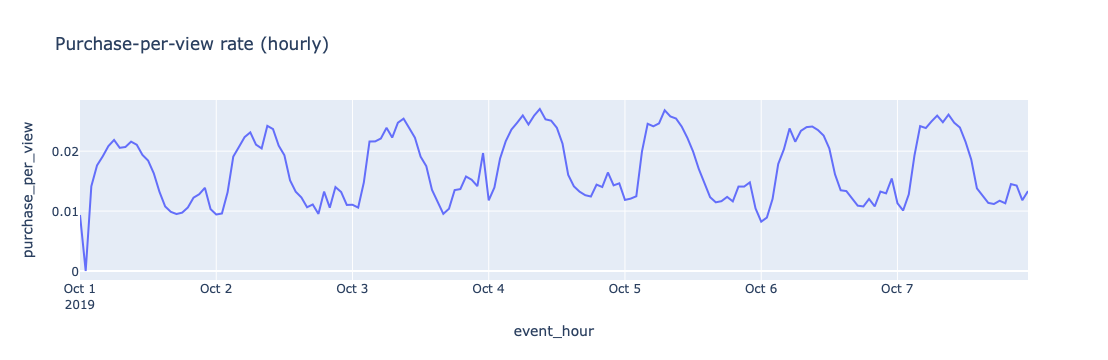

Done. Next: run clickhouse.example.ipynb to train models on training_sessions_n5.


In [ ]:
print("Step 9/9: Final visuals")

df_hour = ch_df(
    client,
    """
    SELECT event_hour, views, carts, purchases,
           purchases / nullIf(views,0) AS purchase_per_view
    FROM hourly_funnel
    ORDER BY event_hour
    LIMIT 24*7
    """,
    ["event_hour","views","carts","purchases","purchase_per_view"],
)

fig = px.line(df_hour, x="event_hour", y="purchase_per_view", title="Purchase-per-view rate (hourly)")
fig.show()

print("Done. Next: run clickhouse.example.ipynb to train models on training_sessions_n5.")